# Image Classification with ResNet-18 on CIFAR-10 Dataset

In [32]:
# 🔹 Core
import torch # Derin öğrenme modelleri oluşturmak ve eğitmek için kullanılan bir kütüphane 
import numpy as np # Bilimsel hesaplamalar için kullanılan bir kütüphane

# 🔹 Neural Network
import torch.nn as nn # Sinir ağı katmanları ve yapıları için kullanılan bir modül
import torch.nn.functional as F # Sinir ağı fonksiyonları için kullanılan bir modül
import torch.optim as optim # Optimizasyon algoritmaları için kullanılan bir modül

# 🔹 Vision
import torchvision # Görüntü işleme ve veri setleri için kullanılan bir kütüphane
from torchvision import transforms # Görüntü dönüşümleri ve veri ön işleme için kullanılan bir modül
from torchvision import models # Önceden eğitilmiş modelleri içeren bir modül

# 🔹 Data
from torch.utils.data import DataLoader # Veri setlerini yüklemek ve işlemek için kullanılan bir modül

# 🔹 Visualization
import matplotlib.pyplot as plt # Grafik çizimi için kullanılan bir kütüphane
import seaborn as sns # Veri görselleştirme için kullanılan bir kütüphane

# 🔹 Metrics
from sklearn.metrics import confusion_matrix # Sınıflandırma modellerinin performansını değerlendirmek için kullanılan bir metrik

In [33]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu') # Modelin ve verilerin taşınacağı cihazı belirler. 
# Eğer CUDA destekli bir GPU varsa, 'cuda' olarak ayarlanır; aksi takdirde 'cpu' olarak ayarlanır. 
# Bu, modelin ve verilerin hangi cihazda işleneceğini belirlemek için kullanılır. 
# GPU'lar, derin öğrenme modellerinin eğitimini hızlandırmak için yaygın olarak kullanılır, bu nedenle mümkünse GPU kullanmak genellikle tercih edilir. 
# Ancak, eğer GPU mevcut değilse, CPU kullanılacaktır.

print(f"Using Device: {device}") # Cihaz bilgisini ekrana yazdırır. 
# Bu, modelin ve verilerin hangi cihazda işleneceğini gösterir.  
# Eğer CUDA destekli bir GPU varsa, 'cuda' olarak yazdırılır; aksi takdirde 'cpu' olarak yazdırılır. 
# Bu bilgi, modelin eğitim ve değerlendirme süreçlerinde hangi cihazın kullanılacağını anlamak için önemlidir.

Using Device: cpu


In [34]:
# ResNet-18, derin öğrenme modelleri arasında popüler bir konvolüsyonel sinir ağı (CNN) mimarisidir ve genellikle görüntü sınıflandırma görevlerinde kullanılır.
# ResNet-18, 18 katmanlı bir mimariye sahip olup, residual bağlantılar (skip connections) kullanarak derin ağların eğitimini kolaylaştırır.
# ResNet-18 modeli, ImageNet veri seti üzerinde önceden eğitilmiş ağırlıklarla yüklenebilir, bu da transfer öğrenme gibi tekniklerde kullanılarak yeni veri setleri üzerinde daha hızlı ve daha iyi sonuçlar elde etmek için yaygın olarak kullanılır.

resnet18 = models.resnet18(weights=models.ResNet18_Weights.DEFAULT) # ResNet-18 modelini önceden eğitilmiş ağırlıklarla yükler. 
# models.resnet18() fonksiyonu, ResNet-18 modelini oluşturur
# weights=models.ResNet18_Weights.DEFAULT ifadesi, modelin önceden eğitilmiş ağırlıklarla yüklenmesini sağlar. 
# Bu, modelin ImageNet veri seti üzerinde eğitilmiş ağırlıklarla başlatılmasını sağlar, böylece modelin genel özellikleri ve görsel tanıma yetenekleri geliştirilmiş olur. 
# Önceden eğitilmiş modeller, transfer öğrenme gibi tekniklerde kullanılarak, yeni veri setleri üzerinde daha hızlı ve daha iyi sonuçlar elde etmek için yaygın olarak kullanılır.

print(resnet18)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [35]:
for param in resnet18.parameters(): # ResNet-18 modelinin tüm parametrelerini döngü ile iterasyon yapar.
    param.requires_grad = False # Her bir parametrenin gradyan hesaplamalarına dahil edilmemesini sağlar.
# Bu, modelin önceden eğitilmiş ağırlıklarının eğitim sırasında güncellenmemesini sağlar.
# Bu, transfer öğrenme gibi tekniklerde yaygın olarak kullanılır, çünkü önceden eğitilmiş modellerin genel özellikleri ve görsel tanıma yetenekleri korunurken, sadece son katmanlar gibi belirli bölümlerinin eğitilmesi istenebilir.

num_classes = 10 # CIFAR-10 veri setindeki sınıf sayısını temsil eder. CIFAR-10 veri seti, 10 farklı sınıfa sahip bir görüntü sınıflandırma veri setidir.
num_features = resnet18.fc.in_features # ResNet-18 modelinin son tam bağlantılı katmanının giriş özelliklerinin sayısını temsil eder. resnet18.fc ifadesi, ResNet-18 modelinin son tam bağlantılı katmanını temsil eder. in_features ifadesi ise bu katmanın giriş özelliklerinin sayısını verir. Bu, modelin son katmanının giriş boyutunu belirlemek için kullanılır.
resnet18.fc = nn.Linear(num_features, num_classes) # ResNet-18 modelinin son tam bağlantılı (fully connected) katmanını, CIFAR-10 veri setindeki sınıf sayısına uygun şekilde yeniden tanımlar.
# resnet18.fc ifadesi, ResNet-18 modelinin son tam bağlantılı katmanını temsil eder. nn.Linear() fonksiyonu, yeni bir tam bağlantılı katman oluşturur. num_features ifadesi, mevcut son katmanın giriş özelliklerinin sayısını alır ve num_classes ifadesi ise yeni katmanın çıkış özelliklerinin sayısını belirler. Bu, modelin CIFAR-10 veri setindeki 10 sınıfı tahmin edebilmesi için son katmanın yeniden yapılandırılmasını sağlar.

for param in resnet18.fc.parameters(): # ResNet-18 modelinin son tam bağlantılı katmanının tüm parametrelerini döngü ile iterasyon yapar.
    param.requires_grad = True # Her bir parametrenin gradyan hesaplamalarına dahil edilmesini sağlar.
# Bu, modelin son tam bağlantılı katmanının eğitim sırasında güncellenmesini sağlar.
# Bu, transfer öğrenme gibi tekniklerde yaygın olarak kullanılır, çünkü önceden eğitilmiş modellerin genel özellikleri ve görsel tanıma yetenekleri korunurken, sadece son katmanlar gibi belirli bölümlerinin eğitilmesi istenebilir.

resnet18 = resnet18.to(device) # ResNet-18 modelini belirlenen cihaza (CPU veya GPU) taşır.
# Bu, modelin eğitim ve değerlendirme süreçlerinde hangi cihazda işleneceğini belirler.
# GPU'lar, derin öğrenme modellerinin eğitimini hızlandırmak için yaygın olarak kullanılır, bu nedenle mümkünse GPU kullanmak genellikle tercih edilir.

print(resnet18.fc) # ResNet-18 modelinin son tam bağlantılı katmanını ekrana yazdırır.

Linear(in_features=512, out_features=10, bias=True)


CIFAR-10, Canadian Institute For Advanced Research 10 https://www.cs.toronto.edu/~kriz/cifar.html adresinden indirilebilir.

CIFAR-10, 10 sınıfa sahip bir görüntü veri setidir ve genellikle makine öğrenmesi ve derin öğrenme modellerinin performansını değerlendirmek ve farklı algoritmaların karşılaştırılması için bir benchmark olarak hizmet eder. 
- Görüntü sınıflandırma, nesne tanıma ve diğer bilgisayarla görme görevlerinde kullanılır.
- CIFAR-10 veri seti, 10 sınıftan oluşur ve her sınıf 6000 görüntü içerir. Toplamda 60000 görüntü vardır.
- CIFAR-10 veri seti, 60.000 renkli görüntü içerir ve her görüntü 32x32 piksel boyutundadır. 
- CIFAR-10 veri seti, eğitim ve test olmak üzere iki bölüme ayrılmıştır: eğitim seti 50.000 görüntü içerirken, test seti 10.000 görüntü içerir. Her görüntü, aşağıdaki 10 sınıftan birine aittir:
  1. Uçak (airplane)
  2. Araba (automobile)
  3. Kuş (bird)
  4. Kedi (cat)
  5. Geyik (deer)
  6. Köpek (dog)
  7. Kurbağa (frog)
  8. At (horse)
  9. Gemi (ship)
  10. Kamyon (truck)
- CIFAR-10, genellikle eğitim ve test süreçlerinde kullanılan bir veri setidir ve birçok makine öğrenmesi ve derin öğrenme kütüphanesi tarafından desteklenir.
  
> CIFAR-10 veri seti, genellikle derin öğrenme modellerinin performansını değerlendirmek için kullanılır ve özellikle görüntü sınıflandırma görevlerinde yaygın olarak tercih edilir.

In [36]:
# Transformasyonlar için CIFAR-10 veri setinin ortalama ve standart sapma değerleri kullanılır. 
# Bu değerler, görüntülerin renk kanallarının (R, G, B) ortalama ve standart sapma değerlerini temsil eder.
cifar10_mean = (0.4914, 0.4822, 0.4465) # CIFAR-10 veri setindeki görüntülerin ortalama renk değerleri (R, G, B) olarak tanımlanır. 
cifar10_std = (0.2470, 0.2435, 0.2616) # CIFAR-10 veri setindeki görüntülerin standart sapma renk değerleri (R, G, B) olarak tanımlanır.

# 🔹 Train transform (augmentation olabilir)
# Veri artırma (augmentation) işlemi yapılmaz, sadece görüntüler tensöre dönüştürülür ve normalleştirilir.
# Bu, modelin eğitim sırasında görüntüleri daha iyi işlemesine ve genelleme yapmasına yardımcı olabilir.
train_transform = transforms.Compose([
    transforms.ToTensor(), # Görüntüleri tensöre dönüştürmek için kullanılan bir dönüşüm. Modelin eğitim sırasında görüntüleri işleyebilmesi için gereklidir.
    # Tensör dönüşümü, görüntüleri PyTorch'un anlayabileceği bir formata dönüştürür.
    transforms.Normalize(
        mean=cifar10_mean, # CIFAR-10 veri setindeki görüntülerin ortalama renk değerleri (R, G, B) olarak tanımlanır.
        std=cifar10_std # CIFAR-10 veri setindeki görüntülerin standart sapma renk değerleri (R, G, B) olarak tanımlanır.
    ) # Normalleştirme işlemi, görüntülerin renk değerlerini belirli bir aralığa getirir.
]) 

# 🔹 Test transform (augmentation olmaz)
# Test verileri için veri artırma (augmentation) işlemi yapılmaz, sadece görüntüler tensöre dönüştürülür ve normalleştirilir.
# Bu, modelin değerlendirme sırasında daha doğru sonuçlar vermesine yardımcı olur.
test_transform = transforms.Compose([
    transforms.ToTensor(), # Görüntüleri tensöre dönüştürmek için kullanılan bir dönüşüm. Modelin değerlendirme sırasında görüntüleri işleyebilmesi için gereklidir.
    transforms.Normalize(
        mean=cifar10_mean, # CIFAR-10 veri setindeki görüntülerin ortalama renk değerleri (R, G, B) olarak tanımlanır.
        std=cifar10_std # CIFAR-10 veri setindeki görüntülerin standart sapma renk değerleri (R, G, B) olarak tanımlanır.
    )
])

In [37]:
data_root = './data' # CIFAR-10 veri setinin indirileceği ve saklanacağı dizin. 
# Bu dizin, veri setinin boyutuna bağlı olarak yeterli depolama alanına sahip olmalıdır.

train_dataset = torchvision.datasets.CIFAR10(
    root=data_root, # CIFAR-10 veri setinin indirileceği ve saklanacağı dizin. 
    train=True, # Eğitim verilerini yüklemek için kullanılan bir parametre. True olarak ayarlandığında, eğitim verileri yüklenir.
    download=True, # Veri seti belirtilen dizinde bulunamazsa, internetten indirir.
    transform=train_transform # Eğitim verileri için uygulanacak dönüşümler.
) # CIFAR-10 veri setinin eğitim verilerini yükler ve belirtilen dönüşümleri uygular. Veri seti belirtilen dizinde bulunmazsa, internetten indirir.

test_dataset = torchvision.datasets.CIFAR10(
    root=data_root, # CIFAR-10 veri setinin indirileceği ve saklanacağı dizin.
    train=False, # Test verilerini yüklemek için kullanılan bir parametre. False olarak ayarlandığında, test verileri yüklenir.
    download=True, # Veri seti belirtilen dizinde bulunamazsa, internetten indirir.
    transform=test_transform # Test verileri için uygulanacak dönüşümler.
) # CIFAR-10 veri setinin test verilerini yükler ve belirtilen dönüşümleri uygular. Veri seti belirtilen dizinde bulunmazsa, internetten indirir.

Files already downloaded and verified
Files already downloaded and verified


In [38]:
batch_size = 128 # Modelin eğitim ve değerlendirme sırasında kullanılacak veri örneklerinin sayısı.
num_workers = 4 # Veri yükleyicisinin (DataLoader) kaç iş parçacığı kullanacağını belirler. 
# 4 olarak ayarlandığında, veri yükleyicisi (DataLoader) 4 iş parçacığı kullanarak verileri yükler.
# # Daha yüksek bir değer, veri yükleme işlemini hızlandırabilir, ancak sistem kaynaklarına bağlı olarak performansı etkileyebilir.

train_loader = DataLoader(
    train_dataset, # Eğitim veri setini yüklemek ve işlemek için kullanılan bir veri yükleyici (DataLoader) oluşturur.
    batch_size=batch_size, # Modelin eğitim sırasında kullanılacak veri örneklerinin sayısı.
    shuffle=True, # Eğitim verilerini karıştırarak modelin daha iyi genelleme yapmasına yardımcı olur.
    num_workers=num_workers, # Veri yükleyicisinin (DataLoader) kaç iş parçacığı kullanacağını belirler.
    pin_memory=torch.cuda.is_available() # CUDA destekli bir GPU varsa, veri yükleyicisinin (DataLoader) bellek pinleme özelliğini etkinleştirir. Bu, veri transferini hızlandırabilir ve modelin eğitim performansını artırabilir.
) # Eğitim veri setini yüklemek ve işlemek için kullanılan bir veri yükleyici (DataLoader) oluşturur. 
# Eğitim verilerini karıştırarak modelin daha iyi genelleme yapmasına yardımcı olur. 

test_loader = DataLoader(
    test_dataset, # Test veri setini yüklemek ve işlemek için kullanılan bir veri yükleyici (DataLoader) oluşturur. 
    batch_size=batch_size, # Modelin değerlendirme sırasında kullanılacak veri örneklerinin sayısı.
    shuffle=False,  # Test verilerini karıştırmamak önemlidir.
    num_workers=num_workers, # Veri yükleyicisinin (DataLoader) kaç iş parçacığı kullanacağını belirler.
    pin_memory=torch.cuda.is_available() # CUDA destekli bir GPU varsa, veri yükleyicisinin (DataLoader) bellek pinleme özelliğini etkinleştirir.
) # Test veri setini yüklemek ve işlemek için kullanılan bir veri yükleyici (DataLoader) oluşturur.

In [39]:
images, labels = next(iter(train_loader)) # Eğitim veri yükleyicisinden (train_loader) bir batch (küme) veri alır.
# next(iter(train_loader)) ifadesi, train_loader veri yükleyicisinden bir batch veri almak için kullanılır.
# Bu, veri yükleyicisinden bir batch veri almak için kullanılan bir yöntemdir.

# images değişkeni, alınan batch içindeki görüntüleri içerir.
# labels değişkeni ise bu görüntülere karşılık gelen etiketleri içerir.
# Bu işlem, modelin eğitim sürecinde kullanılacak veri örneklerini ve etiketleri elde etmek için yapılır.

print(
    f'Image Shape: {images.shape}\n'
    f'Labels Shape: {labels.shape}'
)

# [128, 3, 32, 32] -> [batch_size, channels, height, width]
# Bu çıktı, eğitim veri yükleyicisinden (train_loader) alınan görüntülerin ve etiketlerin şekillerini gösterir.
# Görüntüler 128 örnek içerir (batch_size), her biri 3 renk kanalına (R, G, B) ve 32x32 piksel boyutuna sahiptir. 
# Etiketler de 128 örnek içerir, her biri bir sınıfı temsil eder.
# Bu bilgiler, modelin giriş ve çıkış boyutlarını belirlemek için önemlidir.

# Görüntülerin şekli, modelin ilk katmanında beklenen giriş boyutunu belirler.
# Etiketlerin şekli, modelin son katmanında beklenen çıkış boyutunu belirler.
# Bu bilgiler, modelin mimarisini tasarlarken ve eğitim sürecini optimize ederken kritik öneme sahiptir.

# Görüntülerin ve etiketlerin şekillerini anlamak, modelin doğru şekilde yapılandırılmasını sağlar ve eğitim sürecinin sorunsuz bir şekilde ilerlemesine yardımcı olur.

Image Shape: torch.Size([128, 3, 32, 32])
Labels Shape: torch.Size([128])


In [40]:
criterion = nn.CrossEntropyLoss() # Sınıflandırma problemleri için yaygın olarak kullanılan bir kayıp fonksiyonudur.
# CrossEntropyLoss, modelin tahminleri ile gerçek etiketler arasındaki farkı ölçer ve modelin öğrenme sürecinde bu farkı minimize etmeye çalışır.

optimizer = optim.Adam(
    resnet18.parameters(), # Modelin öğrenme sürecinde güncellenecek parametrelerini belirtir. Bu, modelin ağırlıklarını ve biaslarını içerir.
    lr=1e-3, # Öğrenme oranı (learning rate) olarak 0.001 (1e-3) kullanılır. Bu, modelin ağırlıklarını güncellerken ne kadar büyük adımlar atacağını belirler.
    weight_decay=1e-4 # Ağırlık çürümesi (weight decay) olarak 0.0001 (1e-4) kullanılır. Bu, modelin ağırlıklarının güncellenirken küçük bir ceza uygulanmasını sağlar ve overfitting'i önlemeye yardımcı olabilir.
) # Adam optimizasyon algoritması, modelin parametrelerini güncellemek için kullanılır.
# Adam optimizasyon algoritması, modelin parametrelerini güncellemek için kullanılan bir yöntemdir.
# Adam, öğrenme oranını adaptif olarak ayarlayan bir optimizasyon algoritmasıdır ve genellikle derin öğrenme modellerinde iyi performans gösterir.
# Adam, modelin parametrelerini güncellerken momentum ve RMSProp gibi teknikleri kullanarak daha hızlı ve daha etkili bir şekilde öğrenmeyi sağlar.

In [41]:
def train_model(model, dataloader, criterion, optimizer, device): # Modelin eğitim sürecini gerçekleştiren bir fonksiyon tanımlar. Bu fonksiyon, modelin eğitim moduna geçmesini sağlar, her batch için kayıp değerini hesaplar, gradyanları geri yayar ve modelin parametrelerini günceller.
    # Bu fonksiyon, modelin eğitim sürecini yönetir ve her epoch sonunda ortalama kayıp ve doğruluk değerlerini döndürür.
    # Modelin eğitim sürecinde, her batch için kayıp değeri hesaplanır, gradyanlar geri yayılır ve modelin parametreleri güncellenir.
    
    # Bu fonksiyon, modelin eğitim sürecini yönetmek ve modelin performansını değerlendirmek için kullanılır.
    # model: Eğitilecek konvolüsyonel sinir ağı (CNN) modelini temsil eder.
    # dataloader: Eğitim verilerini yüklemek ve işlemek için kullanılan bir veri yükleyici (DataLoader) nesnesini temsil eder.
    # criterion: Modelin tahminleri ile gerçek etiketler arasındaki kaybı hesaplamak için kullanılan bir kayıp fonksiyonunu temsil eder.    
    # optimizer: Modelin parametrelerini güncellemek için kullanılan bir optimizasyon algoritmasını temsil eder.
    # device: Modelin ve verilerin taşınacağı cihazı (CPU veya GPU) temsil eder.

    model.train() # Modelin eğitim moduna geçmesini sağlar. Bu, dropout ve batch normalization gibi katmanların eğitim sırasında farklı davranmasını sağlar.
    # Modelin eğitim moduna geçmesi, modelin eğitim sırasında doğru şekilde çalışmasını sağlar.

    running_loss = 0.0 # Eğitim sürecinde kaybedilen toplam kayıp değerini tutar. Her batch için hesaplanan kayıp değerleri bu değişkende toplanır.
    correct = 0 # Eğitim sürecinde doğru sınıflandırılan örneklerin sayısını tutar. Her batch için doğru sınıflandırılan örnekler bu değişkende toplanır.
    total = 0 # Eğitim sürecinde işlenen toplam örnek sayısını tutar. Her batch için işlenen örnekler bu değişkende toplanır.

    for batch_idx, (inputs, targets) in enumerate(dataloader): # Eğitim veri yükleyicisinden (dataloader) her batch için giriş verilerini (inputs) ve hedef etiketleri (targets) alır.
        inputs = inputs.to(device) # Giriş verilerini belirtilen cihaza (CPU veya GPU) taşır. Bu, modelin eğitim sürecinde verileri işleyebilmesi için gereklidir.
        targets = targets.to(device) # Hedef etiketleri belirtilen cihaza (CPU veya GPU) taşır. Bu, modelin eğitim sürecinde hedef etiketleri işleyebilmesi için gereklidir.

        optimizer.zero_grad() # Optimizatörün (optimizer) gradyanlarını sıfırlar. Bu, her batch için gradyanların birikmesini önler ve modelin doğru şekilde güncellenmesini sağlar.

        outputs = model(inputs) # Modelin ileri besleme (forward) metodunu çağırarak giriş verilerini işler ve tahminler (logits) üretir.
        loss = criterion(outputs, targets) # Modelin tahminleri (outputs) ile gerçek etiketler (targets) arasındaki kaybı hesaplar. Bu, modelin öğrenme sürecinde minimize etmeye çalıştığı bir değerdir.

        loss.backward() # Geri yayılım (backward) işlemini gerçekleştirir. Bu, kaybın modelin parametrelerine göre türevini hesaplar.
        optimizer.step() # Optimizatörün (optimizer) adımını atar. Bu, modelin parametrelerini günceller ve öğrenme sürecini ilerletir.

        running_loss += loss.item() * inputs.size(0) # Her batch için kayıp değerini running_loss değişkenine ekler. loss.item() ifadesi, kayıp değerini bir Python sayısına dönüştürür ve inputs.size(0) ifadesi, batch içindeki örnek sayısını verir. Bu, toplam kayıp değerini hesaplamak için kullanılır.

        _, predicted = outputs.max(1) # Modelin tahminlerini (outputs) alır ve her örnek için en yüksek olasılığa sahip sınıfı belirler. predicted değişkeni, modelin tahmin ettiği sınıf indekslerini içerir.

        total += targets.size(0) # Her batch için işlenen örnek sayısını total değişkenine ekler. targets.size(0) ifadesi, batch içindeki örnek sayısını verir. Bu, toplam işlenen örnek sayısını hesaplamak için kullanılır.
        correct += (predicted == targets).sum().item() # Modelin tahmin ettiği sınıfların (predicted) gerçek etiketlerle (targets) eşleşip eşleşmediğini kontrol eder ve doğru sınıflandırılan örneklerin sayısını correct değişkenine ekler. (predicted == targets) ifadesi, her örnek için tahmin edilen sınıfın gerçek sınıf ile eşleşip eşleşmediğini kontrol eder ve sum() ifadesi, doğru sınıflandırılan örneklerin toplam sayısını verir.
        
    epoch_loss = running_loss / total # Eğitim sürecinde kaybedilen toplam kayıp değerini, işlenen toplam örnek sayısına bölerek ortalama kayıp değerini hesaplar. Bu, modelin eğitim sürecindeki performansını değerlendirmek için kullanılır.
    epoch_acc = correct / total # Eğitim sürecinde doğru sınıflandırılan örneklerin oranını hesaplar. Bu, modelin eğitim sürecindeki doğruluk performansını değerlendirmek için kullanılır.

    return epoch_loss, epoch_acc # Eğitim sürecinde ortalama kayıp ve doğruluk değerlerini döndürür. Bu değerler, modelin eğitim sürecindeki performansını değerlendirmek için kullanılır.

In [42]:
def evaluate(model, dataloader, criterion, device): # Modelin değerlendirme sürecini gerçekleştiren bir fonksiyon tanımlar. Bu fonksiyon, modelin değerlendirme moduna geçmesini sağlar, her batch için kayıp değerini hesaplar ve modelin doğruluk performansını ölçer.
    # Bu fonksiyon, modelin değerlendirme sürecini yönetir ve ortalama kayıp ve doğruluk değerlerini döndürür.
    # Modelin değerlendirme sürecinde, her batch için kayıp değeri hesaplanır ve modelin doğruluk performansı ölçülür.
    # model: Değerlendirilecek konvolüsyonel sinir ağı (CNN) modelini temsil eder.
    # dataloader: Değerlendirme verilerini yüklemek ve işlemek için kullanılan bir veri yükleyici (DataLoader) nesnesini temsil eder.
    # criterion: Modelin tahminleri ile gerçek etiketler arasındaki kaybı hesaplamak için kullanılan bir kayıp fonksiyonunu temsil eder.
    # device: Modelin ve verilerin taşınacağı cihazı (CPU veya GPU) temsil eder.
    
    model.eval() # Modelin değerlendirme moduna geçmesini sağlar. Bu, dropout ve batch normalization gibi katmanların değerlendirme sırasında farklı davranmasını sağlar.

    running_loss = 0.0 # Değerlendirme sürecinde kaybedilen toplam kayıp değerini tutar. Her batch için hesaplanan kayıp değerleri bu değişkende toplanır.
    correct = 0 # Değerlendirme sürecinde doğru sınıflandırılan örneklerin sayısını tutar. Her batch için doğru sınıflandırılan örnekler bu değişkende toplanır.
    total = 0 # Değerlendirme sürecinde işlenen toplam örnek sayısını tutar. Her batch için işlenen örnekler bu değişkende toplanır.

    with torch.no_grad(): # Geri yayılımın (backward) hesaplanmasını devre dışı bırakır. Bu, değerlendirme sürecinde gereksiz hesaplamaları önler ve bellek kullanımını azaltır.
        for inputs, targets in dataloader: # Değerlendirme sürecinde her batch için giriş verilerini (inputs) ve hedef etiketleri (targets) alır.
            inputs = inputs.to(device) # Giriş verilerini belirtilen cihaza (CPU veya GPU) taşır. Bu, modelin değerlendirme sürecinde verileri işleyebilmesi için gereklidir.
            targets = targets.to(device) # Hedef etiketleri belirtilen cihaza (CPU veya GPU) taşır. Bu, modelin değerlendirme sürecinde hedef etiketleri işleyebilmesi için gereklidir.

            outputs = model(inputs) # Modelin ileri besleme (forward) metodunu çağırarak giriş verilerini işler ve tahminler (logits) üretir.
            loss = criterion(outputs, targets) # Modelin tahminleri (outputs) ile gerçek etiketler (targets) arasındaki kaybı hesaplar. Bu, modelin değerlendirme sürecinde performansını ölçmek için kullanılır.

            running_loss += loss.item() * inputs.size(0) # Her batch için kayıp değerini running_loss değişkenine ekler. loss.item() ifadesi, kayıp değerini bir Python sayısına dönüştürür ve inputs.size(0) ifadesi, batch içindeki örnek sayısını verir. Bu, toplam kayıp değerini hesaplamak için kullanılır.

            _, predicted = outputs.max(1) # Modelin tahminlerini (outputs) alır ve her örnek için en yüksek olasılığa sahip sınıfı belirler. predicted değişkeni, modelin tahmin ettiği sınıf indekslerini içerir.

            total += targets.size(0) # Her batch için işlenen örnek sayısını total değişkenine ekler. targets.size(0) ifadesi, batch içindeki örnek sayısını verir. Bu, toplam işlenen örnek sayısını hesaplamak için kullanılır.
            correct += (predicted == targets).sum().item() # Modelin tahmin ettiği sınıfların (predicted) gerçek etiketlerle (targets) eşleşip eşleşmediğini kontrol eder ve doğru sınıflandırılan örneklerin sayısını correct değişkenine ekler. (predicted == targets) ifadesi, her örnek için tahmin edilen sınıfın gerçek sınıf ile eşleşip eşleşmediğini kontrol eder ve sum() ifadesi, doğru sınıflandırılan örneklerin toplam sayısını verir.

    epoch_loss = running_loss / total # Değerlendirme sürecinde kaybedilen toplam kayıp değerini, işlenen toplam örnek sayısına bölerek ortalama kayıp değerini hesaplar. Bu, modelin değerlendirme sürecindeki performansını ölçmek için kullanılır.
    epoch_acc = correct / total # Değerlendirme sürecinde doğru sınıflandırılan örneklerin oranını hesaplar. Bu, modelin değerlendirme sürecindeki doğruluk performansını ölçmek için kullanılır.

    return epoch_loss, epoch_acc # Değerlendirme sürecinde ortalama kayıp ve doğruluk değerlerini döndürür. Bu değerler, modelin değerlendirme sürecindeki performansını ölçmek için kullanılır.

In [43]:
NUM_EPOCHS = 100 # Modelin eğitim sürecinde kaç epoch (tam veri seti üzerinden geçiş) gerçekleştirileceğini belirler.
BEST_VAL_LOSS = float('inf') # Modelin değerlendirme sürecinde elde edilen en düşük kayıp değerini tutar. Bu, modelin performansını izlemek ve en iyi modeli kaydetmek için kullanılabilir.

patience = 5 # Modelin değerlendirme sürecinde kayıp değerinin iyileşmediği epoch sayısının eşik değeri.
counter = 0 # Modelin değerlendirme sürecinde kayıp değerinin iyileşmediği epoch sayısını tutar. Bu, erken durdurma (early stopping) mekanizması için kullanılabilir.

train_losses = [] # Eğitim sürecinde her epoch sonunda kaybedilen ortalama kayıp değerlerini tutar. Bu, modelin eğitim sürecindeki performansını izlemek için kullanılabilir.
train_accuracies = [] # Eğitim sürecinde her epoch sonunda doğruluk değerlerini tutar. Bu, modelin eğitim sürecindeki performansını izlemek için kullanılabilir.
val_losses = [] # Doğrulama sürecinde her epoch sonunda kaybedilen ortalama kayıp değerlerini tutar. Bu, modelin doğrulama sürecindeki performansını izlemek için kullanılabilir.
val_accuracies = [] # Doğrulama sürecinde her epoch sonunda doğruluk değerlerini tutar. Bu, modelin doğrulama sürecindeki performansını izlemek için kullanılabilir.

for epoch in range(1, NUM_EPOCHS + 1):

    # Eğitim aşaması
    train_loss, train_acc = train_model(
        model=resnet18, # Eğitilecek konvolüsyonel sinir ağı (ResNet18) modelini temsil eder.
        dataloader=train_loader, # Eğitim verilerini yüklemek ve işlemek için kullanılan bir veri yükleyici (DataLoader) nesnesini temsil eder.
        criterion=criterion, # Modelin tahminleri ile gerçek etiketler arasındaki kaybı hesaplamak için kullanılan bir kayıp fonksiyonunu temsil eder.
        optimizer=optimizer, # Modelin parametrelerini güncellemek için kullanılan bir optimizasyon algoritmasını temsil eder.
        device=device # Modelin ve verilerin taşınacağı cihazı (CPU veya GPU) temsil eder.
    ) # Modelin eğitim sürecini gerçekleştirir ve her epoch sonunda ortalama kayıp ve doğruluk değerlerini döndürür.

    # Değerlendirme aşaması
    val_loss, val_acc = evaluate(
        model=resnet18, # Değerlendirilecek konvolüsyonel sinir ağı (ResNet18) modelini temsil eder.
        dataloader=test_loader, # Değerlendirme verilerini yüklemek ve işlemek için kullanılan bir veri yükleyici (DataLoader) nesnesini temsil eder.
        criterion=criterion, # Modelin tahminleri ile gerçek etiketler arasındaki kaybı hesaplamak için kullanılan bir kayıp fonksiyonunu temsil eder.
        device=device # Modelin ve verilerin taşınacağı cihazı (CPU veya GPU) temsil eder.
    ) # Modelin değerlendirme sürecini gerçekleştirir ve ortalama kayıp ve doğruluk değerlerini döndürür.

    train_losses.append(train_loss) # Eğitim sürecinde her epoch sonunda kaybedilen ortalama kayıp değerlerini train_losses listesine ekler. Bu, modelin eğitim sürecindeki performansını izlemek için kullanılabilir.
    train_accuracies.append(train_acc) # Eğitim sürecinde her epoch sonunda doğruluk değerlerini train_accuracies listesine ekler. Bu, modelin eğitim sürecindeki performansını izlemek için kullanılabilir.
    val_losses.append(val_loss) # Doğrulama sürecinde her epoch sonunda kaybedilen ortalama kayıp değerlerini val_losses listesine ekler. Bu, modelin doğrulama sürecindeki performansını izlemek için kullanılabilir.
    val_accuracies.append(val_acc) # Doğrulama sürecinde her epoch sonunda doğruluk değerlerini val_accuracies listesine ekler. Bu, modelin doğrulama sürecindeki performansını izlemek için kullanılabilir.

    # Eğer bu epoch'taki validation loss daha iyiyse, en iyi modeli kaydet
    if val_loss < BEST_VAL_LOSS:
        BEST_VAL_LOSS = val_loss # Modelin değerlendirme sürecinde elde edilen en düşük kayıp değerini günceller. Bu, modelin performansını izlemek ve en iyi modeli kaydetmek için kullanılabilir.
        counter = 0 # Modelin değerlendirme sürecinde kayıp  değerinin iyileşmediği epoch sayısını sıfırlar. Bu, erken durdurma (early stopping) mekanizması için kullanılabilir.
        torch.save(resnet18.state_dict(), 'best_resnet18.pth') # Modelin ağırlıklarını 'best_resnet18.pth' adlı bir dosyaya kaydeder. Bu, modelin en iyi performans gösterdiği ağırlıkları saklamak için kullanılır.
        print(f'New best model saved with validation loss: {BEST_VAL_LOSS:.4f}') # Yeni en iyi modelin kaydedildiğini ve kayıp değerini ekrana yazdırır.
    else:
        counter += 1 # Modelin değerlendirme sürecinde kayıp değerinin iyileşmediği epoch sayısını artırır. Bu, erken durdurma (early stopping) mekanizması için kullanılabilir.

    print(
        f'Epoch [{epoch:02}/{NUM_EPOCHS}] | '
        f'Training Loss: {train_loss:.4f} | '
        f'Training Accuracy: {train_acc*100:.2f}% | '
        f'Validation Loss: {val_loss:.4f} | '
        f'Validation Accuracy: {val_acc*100:.2f}%'
    ) # Her epoch sonunda eğitim ve doğrulama kayıp ve doğruluk değerlerini ekrana yazdırır.

    # Belirlenen patience kadar iyileşme olmadıysa eğitimi durdur
    if counter >= patience:
        print(f'Early stopping triggered after {patience} epochs without improvement.') # Erken durdurma (early stopping) mekanizmasının tetiklendiğini ekrana yazdırır.
        break # Eğitim döngüsünden çıkar. Bu, modelin kayıp değerinin iyileşmediği epoch sayısı belirli bir eşik değere ulaştığında eğitim sürecini durdurmak için kullanılır.

New best model saved with validation loss: 1.6334
Epoch [01/100] | Training Loss: 1.7659 | Training Accuracy: 38.39% | Validation Loss: 1.6334 | Validation Accuracy: 43.14%
New best model saved with validation loss: 1.5818
Epoch [02/100] | Training Loss: 1.5925 | Training Accuracy: 44.72% | Validation Loss: 1.5818 | Validation Accuracy: 45.53%
New best model saved with validation loss: 1.5786
Epoch [03/100] | Training Loss: 1.5635 | Training Accuracy: 45.50% | Validation Loss: 1.5786 | Validation Accuracy: 45.61%
New best model saved with validation loss: 1.5772
Epoch [04/100] | Training Loss: 1.5503 | Training Accuracy: 46.17% | Validation Loss: 1.5772 | Validation Accuracy: 45.50%
New best model saved with validation loss: 1.5631
Epoch [05/100] | Training Loss: 1.5409 | Training Accuracy: 46.61% | Validation Loss: 1.5631 | Validation Accuracy: 46.14%
Epoch [06/100] | Training Loss: 1.5327 | Training Accuracy: 46.72% | Validation Loss: 1.5649 | Validation Accuracy: 46.14%
New best mod

In [44]:
# Eğitim bitince en iyi modeli geri yükle
resnet18.load_state_dict(torch.load("best_resnet18.pth", map_location=device)) # 'best_resnet18.pth' adlı dosyadan modelin ağırlıklarını yükler. Bu, eğitim sürecinde kaydedilen en iyi modelin ağırlıklarını geri yüklemek için kullanılır.
resnet18 = resnet18.to(device) # Modeli belirtilen cihaza (CPU veya GPU) taşır. Bu, modelin değerlendirme sürecinde verileri işleyebilmesi için gereklidir.
resnet18.eval() # Modelin değerlendirme moduna geçmesini sağlar. Bu, dropout ve batch normalization gibi katmanların değerlendirme sırasında farklı davranmasını sağlar.

print("Best model loaded for final evaluation.") # En iyi modelin yüklendiğini ekrana yazdırır.

Best model loaded for final evaluation.


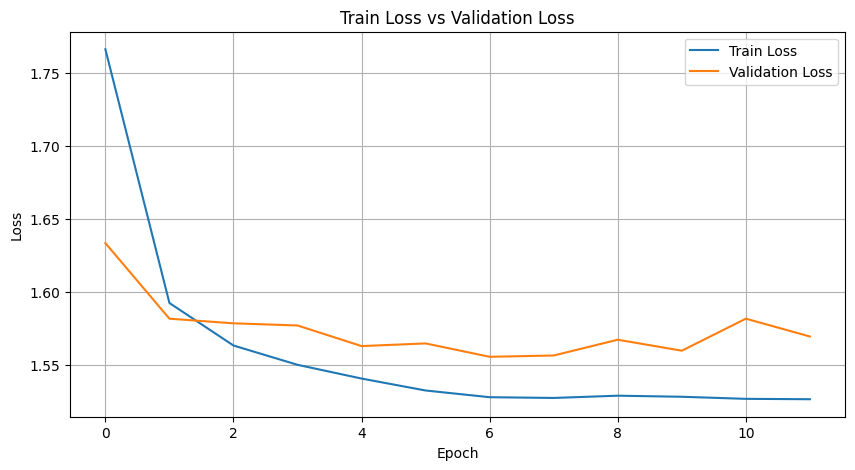

In [45]:
plt.figure(figsize=(10, 5)) # Eğitim ve doğrulama kayıp değerlerini görselleştirmek için bir grafik oluşturur. figsize=(10, 5) ifadesi, grafiğin boyutunu belirler (genişlik 10 inç, yükseklik 5 inç).

plt.plot(train_losses, label="Train Loss") # Eğitim kayıp değerlerini grafiğe ekler. train_losses ifadesi, her epoch için hesaplanan eğitim kayıp değerlerini içeren bir liste veya diziyi temsil eder. label="Train Loss" ifadesi, grafikte bu çizginin etiketini belirler.
plt.plot(val_losses, label="Validation Loss") # Doğrulama kayıp değerlerini grafiğe ekler. val_losses ifadesi, her epoch için hesaplanan doğrulama kayıp değerlerini içeren bir liste veya diziyi temsil eder. label="Validation Loss" ifadesi, grafikte bu çizginin etiketini belirler.
plt.xlabel("Epoch") # X eksenine "Epoch" etiketini ekler. Bu, grafikteki x ekseninin neyi temsil ettiğini belirtir.
plt.ylabel("Loss") # Y eksenine "Loss" etiketini ekler. Bu, grafikteki y ekseninin neyi temsil ettiğini belirtir.
plt.title("Train Loss vs Validation Loss") # Grafiğe başlık ekler. Bu, grafiğin neyi temsil ettiğini açıklar.

plt.legend() # Grafikteki çizgilerin etiketlerini gösterir. Bu, hangi çizginin hangi veriyi temsil ettiğini anlamayı kolaylaştırır.
plt.grid() # Grafiğe ızgara ekler. Bu, grafikteki değerlerin okunmasını kolaylaştırır.
plt.show() # Grafiği ekrana gösterir. Bu, matplotlib ile oluşturulan grafiğin görüntülenmesini sağlar.

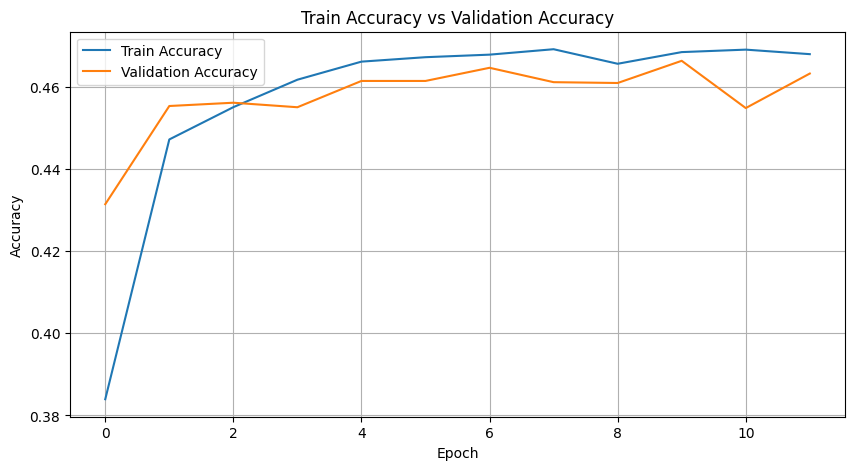

In [46]:
plt.figure(figsize=(10, 5)) # Eğitim ve doğrulama doğruluk değerlerini görselleştirmek için bir grafik oluşturur. figsize=(10, 5) ifadesi, grafiğin boyutunu belirler (genişlik 10 inç, yükseklik 5 inç).

plt.plot(train_accuracies, label="Train Accuracy") # Eğitim doğruluk değerlerini grafiğe ekler. train_accuracies ifadesi, her epoch için hesaplanan eğitim doğruluk değerlerini içeren bir liste veya diziyi temsil eder. label="Train Accuracy" ifadesi, grafikte bu çizginin etiketini belirler.
plt.plot(val_accuracies, label="Validation Accuracy") # Doğrulama doğruluk değerlerini grafiğe ekler. val_accuracies ifadesi, her epoch için hesaplanan doğrulama doğruluk değerlerini içeren bir liste veya diziyi temsil eder. label="Validation Accuracy" ifadesi, grafikte bu çizginin etiketini belirler.
plt.xlabel("Epoch") # X eksenine "Epoch" etiketini ekler. Bu, grafikteki x ekseninin neyi temsil ettiğini belirtir.
plt.ylabel("Accuracy") # Y eksenine "Accuracy" etiketini ekler. Bu, grafikteki y ekseninin neyi temsil ettiğini belirtir.
plt.title("Train Accuracy vs Validation Accuracy") # Grafiğe başlık ekler. Bu, grafiğin neyi temsil ettiğini açıklar.

plt.legend() # Grafikteki çizgilerin etiketlerini gösterir. Bu, hangi çizginin hangi veriyi temsil ettiğini anlamayı kolaylaştırır.
plt.grid() # Grafiğe ızgara ekler. Bu, grafikteki değerlerin okunmasını kolaylaştırır.
plt.show() # Grafiği ekrana gösterir. Bu, matplotlib ile oluşturulan grafiğin görüntülenmesini sağlar.

In [47]:
test_loss, test_acc = evaluate(
    model=resnet18, # Değerlendirilecek konvolüsyonel sinir ağı (ResNet18) modelini temsil eder.
    dataloader=test_loader, # Değerlendirme verilerini yüklemek ve işlemek için kullanılan bir veri yükleyici (DataLoader) nesnesini temsil eder.
    criterion=criterion, # Modelin tahminleri ile gerçek etiketler arasındaki kaybı hesaplamak için kullanılan bir kayıp fonksiyonunu temsil eder.
    device=device # Modelin ve verilerin taşınacağı cihazı (CPU veya GPU) temsil eder.
) # Modelin değerlendirme sürecini gerçekleştirir ve ortalama kayıp ve doğruluk değerlerini döndürür.

print(
    f'RestNet18 Final Test Loss Score: {test_loss:.2f}\n'
    f'RestNet18 Final Test Accuracy Score: {test_acc*100:.2f}%'
) # Modelin test veri seti üzerindeki kayıp ve doğruluk değerlerini ekrana yazdırır. 
# Bu, modelin genel performansını değerlendirmek için kullanılır.

RestNet18 Final Test Loss Score: 1.56
RestNet18 Final Test Accuracy Score: 46.46%


True Class Name: airplane
Pred Class Name: airplane
Confidence: 81.42%


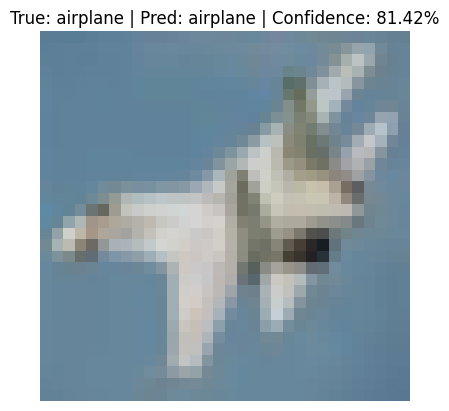

In [48]:
class_names = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
] # CIFAR-10 veri setindeki sınıf adlarını içeren bir liste. Bu liste, modelin tahmin ettiği sınıf indekslerini insan tarafından anlaşılabilir sınıf adlarına dönüştürmek için kullanılır.

idx = 10 # Test veri setinden (test_dataset) belirli bir indeks (idx) ile bir görüntü (image) ve gerçek etiket (true_label) alır. Bu, modelin tek bir örnek üzerinde nasıl performans gösterdiğini değerlendirmek için kullanılır.

image, true_label = test_dataset[idx] # Test veri setinden (test_dataset) belirli bir indeks (idx) ile bir görüntü (image) ve gerçek etiket (true_label) alır.
true_class_name = class_names[true_label] # Gerçek etikete karşılık gelen sınıf adını class_names listesinden alır. true_label ifadesi, gerçek etiketin indeksini temsil eder ve class_names[true_label] ifadesi, bu indekse karşılık gelen sınıf adını verir.

resnet18.eval() # Modelin değerlendirme moduna geçmesini sağlar. Bu, dropout ve batch normalization gibi katmanların değerlendirme sırasında farklı davranmasını sağlar.
with torch.no_grad(): # Geri yayılımın (backward) hesaplanmasını devre dışı bırakır. Bu, değerlendirme sürecinde gereksiz hesaplamaları önler ve bellek kullanımını azaltır.
    
    # image --> [3, 32, 32]
    # image.unsqueeze(0) --> [1, 3, 244, 244]
    input_tensor = image.unsqueeze(0).to(device) # Görüntüyü tek bir örnek içeren bir tensöre dönüştürür ve belirtilen cihaza (CPU veya GPU) taşır. image.unsqueeze(0) ifadesi, görüntüyü tek bir örnek içeren bir tensöre dönüştürür (batch boyutunu ekler) ve to(device) ifadesi, bu tensörü belirtilen cihaza taşır. Bu, modelin değerlendirme sürecinde görüntüyü işleyebilmesi için gereklidir.
    
    outputs = resnet18(input_tensor) # Modelin ileri besleme (forward) metodunu çağırarak giriş tensörünü işler ve tahminler (logits) üretir. input_tensor ifadesi, tek bir görüntüyü içeren bir tensördür ve to(device) ifadesi, bu tensörü belirtilen cihaza (CPU veya GPU) taşır.
    probs = F.softmax(outputs, dim=1) # Modelin tahminlerini (outputs) olasılık değerlerine dönüştürmek için softmax fonksiyonunu uygular. dim=1 ifadesi, softmax işleminin her örnek için uygulanacağını belirtir.
    
    conf, pred_idx = torch.max(probs, dim=1) # Olasılık değerleri arasında en yüksek değeri (conf) ve bu değerin indeksini (pred_idx) bulur. dim=1 ifadesi, her örnek için en yüksek olasılığı bulmak için kullanılır.
    
    pred_idx = pred_idx.item() # pred_idx, tensör içindeki değeri Python sayısına dönüştürür. Bu, modelin tahmin ettiği sınıf indeksini elde etmek için kullanılır.
    conf = conf.item() # conf, tensör içindeki değeri Python sayısına dönüştürür. Bu, modelin tahmin ettiği sınıfın olasılık değerini elde etmek için kullanılır.
    
    pred_class_name = class_names[pred_idx] # Modelin tahmin ettiği sınıf indeksine karşılık gelen sınıf adını class_names listesinden alır. pred_idx ifadesi, modelin tahmin ettiği sınıfın indeksini temsil eder ve class_names[pred_idx] ifadesi, bu indekse karşılık gelen sınıf adını verir.

print(
    f'True Class Name: {true_class_name}\n'
    f'Pred Class Name: {pred_class_name}\n'
    f'Confidence: {conf*100:.2f}%'
)

img_np = image.cpu().numpy().transpose(1, 2, 0) # Görüntüyü CPU'ya taşıdıktan sonra NumPy dizisine dönüştürür ve renk kanallarını (R, G, B) doğru sıraya getirir.
# image.cpu().numpy().transpose(1, 2, 0) ifadesi, görüntüyü CPU'ya taşıdıktan sonra NumPy dizisine dönüştürür ve renk kanallarını (R, G, B) doğru sıraya getirir.

mean = np.array(cifar10_mean) # CIFAR-10 veri setindeki görüntülerin ortalama renk değerleri (R, G, B) olarak tanımlanır. Bu, modelin eğitim sürecinde kullanılan normalizasyon işleminin tersini gerçekleştirmek için kullanılır.
std = np.array(cifar10_std) # CIFAR-10 veri setindeki görüntülerin standart sapma renk değerleri (R, G, B) olarak tanımlanır. Bu, modelin eğitim sürecinde kullanılan normalizasyon işleminin tersini gerçekleştirmek için kullanılır.

img_np = std * img_np + mean # Görüntüyü normalizasyon işleminin tersini gerçekleştirerek orijinal renk değerlerine geri döndürür. std * img_np + mean ifadesi, normalizasyon işleminin tersini gerçekleştirir ve görüntünün orijinal renk değerlerine geri döndürülmesini sağlar.
img_np = np.clip(img_np, 0, 1) # Görüntünün renk değerlerini 0 ile 1 arasında sınırlamak için np.clip fonksiyonunu kullanır. Bu, görüntünün görselleştirilmesi sırasında renk değerlerinin geçerli bir aralıkta kalmasını sağlar.

plt.imshow(img_np) # Görüntüyü ekrana gösterir. img_np ifadesi, normalizasyon işleminin tersini gerçekleştirerek orijinal renk değerlerine geri döndürülmüş bir NumPy dizisini temsil eder. Bu, matplotlib ile görüntünün görselleştirilmesini sağlar.
plt.axis('off') # Görüntünün etrafındaki eksenleri kapatır. Bu, görüntünün daha temiz ve odaklanmış görünmesini sağlar.
plt.title(f'True: {true_class_name} | Pred: {pred_class_name} | Confidence: {conf*100:.2f}%')
plt.show()